# scOPE end-to-end example

This notebook walks through the complete two-phase scOPE workflow:
1. **Phase 1** — learn latent space from bulk RNA-seq and train mutation classifiers.
2. **Phase 2** — project scRNA-seq into the bulk latent space, infer per-cell mutation probabilities.

**Data notes (BeatAML ID scheme):**
- `labId` / `seq_id`: internal `13-XXXXX` barcodes — RNA and DNA get *different* seq_ids for the same patient, so these cannot be directly joined.
- `dbgap_rnaseq_sample` (`BA*R`): RNA-seq sample IDs used in the harmonized dbGaP expression file.
- `dbgap_dnaseq_sample` (`BA*D`): WES sample IDs used in the dbGaP mutation calls file.
- The clinical file maps `BA*D` → `BA*R` and is required to join mutations to expression.

## 1. Imports & paths

In [1]:
import os

import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt

from scope import BulkPipeline, SingleCellPipeline
from scope.visualization import (
    compute_umap,
    plot_mutation_probabilities,
    plot_scree,
    plot_mutation_heatmap,
)


In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
BEATAML_DIR  = "/Users/ashforda/Desktop/Pathways + Omics/scOPE/scOPE_project_overhaul/scOPE/data/BeatAML"
VANGALEN_DIR = "/Users/ashforda/Desktop/Pathways + Omics/scOPE/scOPE_project_overhaul/scOPE/data/vanGalen_AML_scRNA"
RAW_DIR      = os.path.join(BEATAML_DIR, "publicly_available_and_raw_counts")

# Harmonized dbGaP release — RNA IDs: BA*R, WES IDs: BA*D
bulk_txt   = os.path.join(RAW_DIR, "beataml_waves1to4_norm_exp_dbgap.txt")
mut_path   = os.path.join(RAW_DIR, "beataml_wes_wv1to4_mutations_dbgap.txt")
clin_path  = os.path.join(RAW_DIR, "beataml_wv1to4_clinical.xlsx")
sc_path    = os.path.join(VANGALEN_DIR, "vanGalen_anndata.h5ad")


## 2. Load & prepare bulk RNA-seq

In [3]:
# ── Peek at orientation before loading fully ───────────────────────────────
peek = pd.read_csv(bulk_txt, sep="\t", index_col=0, nrows=3)
print("Raw peek shape (nrows=3):", peek.shape)
print("Row index sample  :", peek.index[:3].tolist())
print("Column name sample:", peek.columns[:3].tolist())


Raw peek shape (nrows=3): (3, 710)
Row index sample  : ['ENSG00000000003', 'ENSG00000000419', 'ENSG00000000457']
Column name sample: ['display_label', 'description', 'biotype']


In [7]:
df_bulk = pd.read_csv(bulk_txt, sep="\t", index_col=0)

# Drop gene metadata columns before transposing
meta_cols = [c for c in df_bulk.columns if not (c.startswith('BA') and c.endswith('R'))]
if meta_cols:
    print(f"Dropping non-sample metadata columns: {meta_cols}")
    df_bulk = df_bulk.drop(columns=meta_cols)

# File is genes × samples — transpose to samples × genes
df_bulk = df_bulk.T

adata_bulk = ad.AnnData(
    X   = df_bulk.values.astype(np.float32),
    obs = pd.DataFrame(index=df_bulk.index),
    var = pd.DataFrame(index=df_bulk.columns),
)

print(f"\nBulk loaded : {adata_bulk.n_obs} samples x {adata_bulk.n_vars} genes")
print(f"Sample IDs  : {adata_bulk.obs_names[:5].tolist()}")
print(f"Gene IDs    : {adata_bulk.var_names[:5].tolist()}")


Dropping non-sample metadata columns: ['display_label', 'description', 'biotype']

Bulk loaded : 707 samples x 22843 genes
Sample IDs  : ['BA2392R', 'BA2611R', 'BA2506R', 'BA2430R', 'BA2448R']
Gene IDs    : ['ENSG00000000003', 'ENSG00000000419', 'ENSG00000000457', 'ENSG00000000460', 'ENSG00000000938']


In [8]:
# ── Remap Ensembl IDs → gene symbols (if needed) ──────────────────────────
if adata_bulk.var_names[0].startswith('ENSG'):
    import mygene
    mg = mygene.MyGeneInfo()
    result = mg.querymany(
        adata_bulk.var_names.tolist(),
        scopes='ensembl.gene', fields='symbol',
        species='human', as_dataframe=True
    )
    id2sym = result['symbol'].dropna().to_dict()
    adata_bulk.var_names = pd.Index([id2sym.get(g, g) for g in adata_bulk.var_names])
    adata_bulk = adata_bulk[:, ~adata_bulk.var_names.str.startswith('ENSG')].copy()
    adata_bulk.var_names_make_unique()
    print(f"After gene remapping : {adata_bulk.n_obs} samples x {adata_bulk.n_vars} genes")
else:
    print(f"Gene IDs already symbols — skipping remap. ({adata_bulk.var_names[0]!r})")

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
3 input query terms found dup hits:	[('ENSG00000175711', 2), ('ENSG00000215156', 2), ('ENSG00000259182', 2)]
1137 input query terms found no hit:	['ENSG00000005955', 'ENSG00000006074', 'ENSG00000006075', 'ENSG00000006114', 'ENSG00000017373', 'ENS


After gene remapping : 707 samples x 19975 genes


/opt/homebrew/Cellar/micromamba/2.5.0_1/envs/scope-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## 3. Build mutation label matrix

The dbGaP mutations file uses `dbgap_sample_id` (`BA*D`, DNA).  
The bulk expression file uses `BA*R` (RNA) IDs.  
The clinical file maps `BA*D` → `BA*R` so we can join them.

In [9]:
# ── Build BA*D → BA*R map from clinical file ───────────────────────────────
clin = pd.read_excel(clin_path)
print("Clinical columns:", clin.columns.tolist())

wes_to_rna = (
    clin[['dbgap_dnaseq_sample', 'dbgap_rnaseq_sample']]
    .dropna()
    .set_index('dbgap_dnaseq_sample')['dbgap_rnaseq_sample']
    .to_dict()
)
print(f"BA*D -> BA*R mappings available: {len(wes_to_rna)}")
print("Sample entry:", next(iter(wes_to_rna.items())))


Clinical columns: ['dbgap_subject_id', 'dbgap_dnaseq_sample', 'dbgap_rnaseq_sample', 'cohort', 'used_manuscript_analyses', 'manuscript_dnaseq', 'manuscript_rnaseq', 'manuscript_inhibitor', 'consensus_sex', 'inferred_sex', 'reportedRace', 'reportedEthnicity', 'inferred_ethnicity', 'centerID', 'CEBPA_Biallelic', 'consensusAMLFusions', 'ageAtDiagnosis', 'isRelapse', 'isDenovo', 'isTransformed', 'specificDxAtAcquisition_MDSMPN', 'nonAML_MDSMPN_specificDxAtAcquisition', 'priorMalignancyNonMyeloid', 'priorMalignancyType', 'cumulativeChemo', 'priorMalignancyRadiationTx', 'priorMDS', 'priorMDSMoreThanTwoMths', 'priorMDSMPN', 'priorMDSMPNMoreThanTwoMths', 'priorMPN', 'priorMPNMoreThanTwoMths', 'dxAtInclusion', 'specificDxAtInclusion', 'ELN2017', 'dxAtSpecimenAcquisition', 'specificDxAtAcquisition', 'ageAtSpecimenAcquisition', 'timeOfSampleCollectionRelativeToInclusion', 'specimenGroups', 'diseaseStageAtSpecimenCollection', 'specimenType', 'rnaSeq', 'exomeSeq', 'totalDrug', 'analysisRnaSeq', 'an

In [10]:
# ── Build binary mutation matrix ───────────────────────────────────────────
AML_GENES = ["FLT3", "NPM1", "DNMT3A", "IDH1", "IDH2", "TET2", "RUNX1", "TP53", "NRAS", "KRAS"]

mut_raw = pd.read_csv(mut_path, sep="\t")
print(f"Mutation file shape    : {mut_raw.shape}")
print(f"dbgap_sample_id sample : {mut_raw['dbgap_sample_id'].iloc[:3].tolist()}")

# Map BA*D -> BA*R
mut_raw['rnaseq_id'] = mut_raw['dbgap_sample_id'].map(wes_to_rna)
n_unmapped = mut_raw['rnaseq_id'].isna().sum()
print(f"Rows unmapped to RNA   : {n_unmapped} / {len(mut_raw)} (expected for WES-only samples)")
mut_raw = mut_raw.dropna(subset=['rnaseq_id'])


Mutation file shape    : (11721, 32)
dbgap_sample_id sample : ['BA2336D', 'BA2336D', 'BA2336D']
Rows unmapped to RNA   : 3636 / 11721 (expected for WES-only samples)


In [11]:
mut_matrix = (
    mut_raw[['rnaseq_id', 'symbol']]
    .drop_duplicates()
    .assign(mutated=1)
    .pivot_table(index='rnaseq_id', columns='symbol', values='mutated', fill_value=0)
)
mut_matrix.columns.name = None
mut_matrix.index.name   = None

genes_present = [g for g in AML_GENES if g in mut_matrix.columns]
genes_missing = [g for g in AML_GENES if g not in mut_matrix.columns]
mutation_labels = mut_matrix[genes_present]

print(f"Mutation matrix : {mutation_labels.shape}")
print(f"Genes found     : {genes_present}")
if genes_missing:
    print(f"Genes missing   : {genes_missing}")
    

Mutation matrix : (637, 10)
Genes found     : ['FLT3', 'NPM1', 'DNMT3A', 'IDH1', 'IDH2', 'TET2', 'RUNX1', 'TP53', 'NRAS', 'KRAS']


In [12]:
# ── Intersect bulk samples with mutation calls ─────────────────────────────
shared = adata_bulk.obs_names.intersection(mutation_labels.index)

print(f"Bulk samples total     : {adata_bulk.n_obs}")
print(f"Samples with mut calls : {len(mutation_labels)}")
print(f"Shared (overlap)       : {len(shared)}")

assert len(shared) > 0, (
    "No overlap between bulk BA*R IDs and mutation-mapped BA*R IDs. "
    "Check that bulk_txt is the dbGaP expression file and that the "
    "clinical file has dbgap_dnaseq_sample / dbgap_rnaseq_sample columns."
)

adata_bulk      = adata_bulk[shared].copy()
mutation_labels = mutation_labels.loc[shared]


Bulk samples total     : 707
Samples with mut calls : 637
Shared (overlap)       : 615


## 4. Load single-cell data & sanity checks

In [13]:
adata_sc = ad.read_h5ad(sc_path)
print(f"SC loaded : {adata_sc.n_obs} cells x {adata_sc.n_vars} genes")


SC loaded : 44823 cells x 27899 genes


In [14]:
# ── Sanity checks ──────────────────────────────────────────────────────────
X = adata_bulk.X
print(f"Bulk  : {adata_bulk.n_obs} samples x {adata_bulk.n_vars} genes")
print(f"SC    : {adata_sc.n_obs} cells x {adata_sc.n_vars} genes")
print(f"Muts  : {mutation_labels.shape}")
print()
print(f"NaN count  : {np.isnan(X).sum()}")
print(f"Inf count  : {np.isinf(X).sum()}")
print(f"Min value  : {np.nanmin(X):.3f}")
print(f"Max value  : {np.nanmax(X):.3f}")
print(f"Neg values : {(X < 0).sum()}  (expected if data is already log-normalised)")
print()
print("Mutation frequencies:")
print(mutation_labels.sum().sort_values(ascending=False))
mutation_labels.head()


Bulk  : 615 samples x 19975 genes
SC    : 44823 cells x 27899 genes
Muts  : (615, 10)

NaN count  : 0
Inf count  : 0
Min value  : -9.122
Max value  : 14.501
Neg values : 2577242  (expected if data is already log-normalised)

Mutation frequencies:
NPM1      141.0
DNMT3A    138.0
NRAS       96.0
TET2       82.0
RUNX1      75.0
IDH2       73.0
FLT3       67.0
TP53       57.0
IDH1       49.0
KRAS       34.0
dtype: float64


,FLT3,NPM1,DNMT3A,IDH1,IDH2,TET2,RUNX1,TP53,NRAS,KRAS
BA2452R,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
BA3379R,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
BA2712R,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
BA2068R,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
BA2236R,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


## 5. Phase 1 — Bulk pipeline

The dbGaP expression file is already log-normalised, so `norm_method='none'` and `log1p=False`.  
`n_components` is capped safely below `n_samples`.

In [15]:
n_components = min(100, adata_bulk.n_obs - 1)
print(f"Using n_components = {n_components}")

bulk_pipe = BulkPipeline(
    norm_method='none',
    log1p=False,
    center=True,
    scale=True,
    decomposition='svd',
    n_components=n_components,
    classifier='logistic',
    classifier_kwargs={
        'C': 0.1,
        'class_weight': 'balanced',
        'max_iter': 5000,
        'solver': 'saga',
    },
)
bulk_pipe.fit(adata_bulk, mutation_labels, cv=5)


18:24:17 | INFO     | scope.pipeline.bulk_pipeline — === BulkPipeline.fit ===
18:24:17 | INFO     | scope.pipeline.bulk_pipeline — Preprocessing bulk data (norm=none, log1p=False).
18:24:17 | INFO     | scope.preprocessing.bulk — BulkNormalizer fitted (method=none).
18:24:17 | INFO     | scope.preprocessing.bulk — BulkScaler fitted (center=True, scale=True).


Using n_components = 100


18:24:17 | INFO     | scope.pipeline.bulk_pipeline — Decomposition: svd (k=100).
18:24:18 | INFO     | scope.decomposition.svd — SVD fitted: 100 components (cumulative EVR=0.792).
18:24:18 | INFO     | scope.pipeline.bulk_pipeline — Training classifiers (logistic).
/opt/homebrew/Cellar/micromamba/2.5.0_1/envs/scope-dev/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
18:24:18 | INFO     | scope.classification.base — Trained classifier for 'FLT3' (n_pos=67 / n_tot=615).
/opt/homebrew/Cellar/micromamba/2.5.0_1/envs/scope-dev/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
18:24:18 | INFO     | scope.classification.base — Trained classifier for 'NPM1' (n_pos=141 / n_tot=615).
/opt/homebrew/Cellar/micromamba/2.5.0_1/envs/scope-dev/lib/

,norm_method,'none'
,log1p,False
,center,True
,scale,True
,decomposition,'svd'
,n_components,100
,decomposition_kwargs,{}
,classifier,'logistic'
,classifier_kwargs,"{'C': 0.1, 'class_weight': 'balanced', 'max_iter': 5000, 'solver': 'saga'}"
,min_positive_frac,0.05
,scale_features,True


In [16]:
# ── CV results summary ─────────────────────────────────────────────────────
summary = (
    bulk_pipe.cv_results_
    .groupby('mutation')[['auroc', 'auprc', 'brier']]
    .agg(['mean', 'std'])
    .round(3)
)
print(summary)


          auroc         auprc         brier       
           mean    std   mean    std   mean    std
mutation                                          
DNMT3A    0.828  0.047  0.649  0.080  0.247  0.021
FLT3      0.687  0.046  0.218  0.034  0.327  0.033
IDH1      0.917  0.049  0.520  0.154  0.297  0.015
IDH2      0.877  0.037  0.521  0.042  0.262  0.017
KRAS      0.734  0.062  0.221  0.110  0.356  0.006
NPM1      0.969  0.022  0.870  0.075  0.111  0.022
NRAS      0.757  0.056  0.348  0.126  0.295  0.024
RUNX1     0.931  0.049  0.672  0.144  0.239  0.037
TET2      0.794  0.070  0.520  0.085  0.289  0.019
TP53      0.920  0.059  0.788  0.136  0.192  0.011


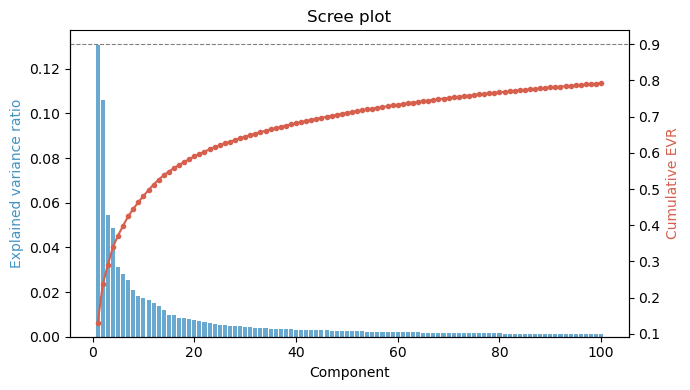

In [17]:
# ── Scree plot ─────────────────────────────────────────────────────────────
scree = bulk_pipe.decomposer_.scree_data()
fig, ax = plot_scree(scree, max_components=n_components)
plt.tight_layout()
plt.show()


## 6. Phase 2 — Single-cell projection

In [18]:
# ── Gene space check ───────────────────────────────────────────────────────
print("Bulk var_names (first 10):", adata_bulk.var_names[:10].tolist())
print("SC   var_names (first 10):", adata_sc.var_names[:10].tolist())

overlap = adata_bulk.var_names.intersection(adata_sc.var_names)
print(f"\nShared genes (bulk intersect SC): {len(overlap)}")


Bulk var_names (first 10): ['TSPAN6', 'DPM1', 'SCYL3', 'FIRRM', 'FGR', 'CFH', 'FUCA2', 'GCLC', 'NFYA', 'STPG1']
SC   var_names (first 10): ['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1', 'A2ML1', 'A2MP1', 'A3GALT2', 'A4GALT', 'A4GNT']

Shared genes (bulk intersect SC): 15498


In [ ]:
# ── Fit & transform single-cell pipeline ──────────────────────────────────
adata_bulk_pp = bulk_pipe.preprocessor_.transform(adata_bulk)

sc_pipe = SingleCellPipeline(
    bulk_pipeline=bulk_pipe,
    alignment_method='z_score_bulk',
    sc_min_counts=200,
    sc_min_genes=200,
)
sc_pipe.fit(adata_bulk_pp, adata_sc)
adata_sc = sc_pipe.transform(adata_sc)

prob_cols = [c for c in adata_sc.obs.columns if c.startswith('mutation_prob_')]
print('Mutation probability columns:', prob_cols)
adata_sc.obs[prob_cols].describe()


18:24:55 | INFO     | scope.pipeline.sc_pipeline — === SingleCellPipeline.fit ===
18:24:55 | INFO     | scope.preprocessing.single_cell — SingleCellPreprocessor fitted.
18:25:38 | INFO     | scope.utils.gene_utils — Gene universe: 15498 shared, 4477 bulk-only, 12401 sc-only
18:25:49 | INFO     | scope.preprocessing.alignment — BulkSCAligner fitted (method=z_score_bulk, n_genes=15498).
18:25:49 | INFO     | scope.pipeline.sc_pipeline — SingleCellPipeline.fit complete.
18:25:49 | INFO     | scope.pipeline.sc_pipeline — === SingleCellPipeline.transform ===


## 7. UMAP visualisation

In [ ]:
adata_sc = compute_umap(adata_sc, obsm_key=bulk_pipe.obsm_key_, n_neighbors=15)

fig = plot_mutation_probabilities(
    adata_sc,
    obsm_key='X_umap',
    ncols=3,
)
fig.savefig('mutation_probability_umap.pdf', bbox_inches='tight')
plt.show()


## 8. Cluster-level summary (optional)

Run Leiden clustering via scanpy before this cell if desired.

In [ ]:
# import scanpy as sc
# sc.pp.neighbors(adata_sc, use_rep=bulk_pipe.obsm_key_)
# sc.tl.leiden(adata_sc)

if 'leiden' in adata_sc.obs.columns:
    fig, ax = plot_mutation_heatmap(adata_sc, cluster_key='leiden')
    plt.show()
else:
    print("No 'leiden' column found — run scanpy clustering above first.")
    

## 9. Save outputs

In [ ]:
os.makedirs('models',  exist_ok=True)
os.makedirs('results', exist_ok=True)

bulk_pipe.save('models/bulk_pipeline.pkl')
adata_sc.write_h5ad('results/sc_with_mutation_probs.h5ad')
print("Saved: models/bulk_pipeline.pkl")
print("Saved: results/sc_with_mutation_probs.h5ad")
